# 02 - Kiểm tra Tiền xử lý - Jena Climate (Dự báo Thời tiết Seq2Seq)

Notebook này chứng minh rằng `src/data/preprocessing.py` biến file CSV Jena Climate
thô 10 phút thành một bộ dữ liệu sạch, không gây rò rỉ dữ liệu, sẵn sàng cho mô hình, và
cho thấy bằng chứng **Trước / Sau** cho từng bước chính sách - không chỉ là
quy trình chạy được, mà mỗi phép biến đổi đã làm đúng như chính sách trong
`configs/data.yaml` quy định. Nó chỉ **gọi** quy trình và
kiểm tra đầu ra của nó - toàn bộ logic tiền xử lý nằm trong mô-đun, không phải
ở đây. Không có mô hình nào được huấn luyện trong notebook này.

quy trình: CSV thô -> Làm sạch mốc thời gian -> **Xử lý giá trị mã hóa thiếu (-9999 ->
NaN)** -> lấy mẫu lại theo giờ (trung bình / lớn nhất / trung bình tuần hoàn) -> Tạo
đặc trưng thời gian -> Chỉ báo thiếu dữ liệu -> Chia tách theo thời gian -> Xử lý
Thiếu dữ liệu (khoảng trống ngắn -> điền xuôi, khoảng trống dài -> để lại NaN để đánh dấu
cửa sổ không hợp lệ, mục tiêu -> không bao giờ bù thiếu) -> Chuẩn hóa (`StandardScaler`, chỉ
trên tập huấn luyện) -> Bộ dữ liệu đã xử lý (lấy mẫu cửa sổ trượt là bước sau).

## Vấn đề từ Notebook 01 → bằng chứng của notebook này

| Vấn đề phát hiện trong `01_data_check.ipynb` | Được giải quyết / chứng minh ở đây |
|---|---|
| File thô không sắp theo thời gian, có mốc thời gian trùng lặp | §1 (thô, trước) / §4 (dữ liệu đã xử lý được sắp xếp nghiêm ngặt, lưới giờ đều đặn) |
| Mã giá trị mã hóa thiếu `-9999` trong `wv (m/s)` / `max. wv (m/s)` | §1b (trước) / §2b (sau - không còn giá trị mã hóa thiếu theo nghĩa đen) |
| Nhịp thô 10 phút so với độ phân giải mô hình hóa 1 giờ | §3 (tần suất + kích thước dữ liệu thô so với dữ liệu đã xử lý) |
| Khoảng trống thời gian SHORT / LONG / CRITICAL | §7b (điền xuôi so với loại bỏ cửa sổ, trên một khoảng trống thực tế) |
| Tính mùa vụ theo ngày + theo năm (giờ/tháng số nguyên thô là đặc trưng kém) | §9 (`hour_sin/cos`, `dayofyear_sin/cos` có mặt trong mẫu đã xử lý) |
| Rủi ro bộ chuẩn hóa rò rỉ thống kê val/kiểm thử vào việc chuẩn hóa | §7 (chứng minh khớp chỉ trên huấn luyện) / §7c (°C → điểm z, cùng hàng) |

Các giá trị chính sách trong `configs/data.yaml` (kích thước cửa sổ, tỷ lệ tập dữ liệu, ngưỡng
khoảng trống, giới hạn điền xuôi) được nạp một lần ở dưới đây và được tham chiếu theo
tên xuyên suốt - không bao giờ được gõ lại như giá trị viết cứng.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.data.preprocessing as pp
from src.config import load_data_config

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "jena_climate_2009_2016.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"

# Nguồn cấu hình duy nhất: configs/data.yaml. src/data/preprocessing.py
# đã đọc tỷ lệ chia tập, giới hạn điền xuôi và quy tắc chuẩn hóa từ file này
# (qua DEFAULT_CONFIG). Notebook nạp lại để các phép kiểm tra riêng dùng cùng
# giá trị cấu hình, tránh tạo thêm một bản sao viết cứng.
DATA_CONFIG = load_data_config()

print("Thư mục gốc dự án:", PROJECT_ROOT)
print("Đường dẫn dữ liệu thô tồn tại:", RAW_PATH.exists())
print(f"chính sách: huấn luyện/xác thực/kiểm thử={DATA_CONFIG['split']['train_fraction']:.0%}/"
      f"{DATA_CONFIG['split']['validation_fraction']:.0%}/{DATA_CONFIG['split']['test_fraction']:.0%}, "
      f"resample={DATA_CONFIG['timestamp']['resample_frequency']}, "
      f"forward_fill_max_hours={DATA_CONFIG['missing']['forward_fill_max_hours']} "
      f"(từ configs/data.yaml)")

Thư mục gốc dự án: /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting
Đường dẫn dữ liệu thô tồn tại: True
chính sách: huấn luyện/xác thực/kiểm thử=70%/15%/15%, resample=1h, forward_fill_max_hours=3 (from configs/data.yaml)


## 1. Nạp dữ liệu thô

In [2]:
raw_df = pp.load_raw_data(RAW_PATH)
raw_rows, raw_cols = raw_df.shape
print(f"Số hàng thô: {raw_rows:,}  |  Số cột thô: {raw_cols}")
raw_df.head()

INFO Loaded 420551 raw rows, 15 columns from /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting/data/raw/jena_climate_2009_2016.csv


Số hàng thô: 420,551  |  Số cột thô: 15


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
raw_diffs = raw_df[pp.TIMESTAMP_COLUMN].sort_values().diff().dropna()
raw_mode_minutes = raw_diffs.mode().iloc[0].total_seconds() / 60
print(f"Tần suất lấy mẫu thô (yếu vị): {raw_mode_minutes:.0f} phút")
print(f"Mốc thời gian thô đã được sắp xếp trong tệp: {raw_df[pp.TIMESTAMP_COLUMN].is_monotonic_increasing}")
print(f"Số mốc thời gian thô bị trùng: {raw_df[pp.TIMESTAMP_COLUMN].duplicated().sum()}")

Tần suất lấy mẫu thô (yếu vị): 10 minutes
Mốc thời gian thô đã được sắp xếp trong tệp: False
Số mốc thời gian thô bị trùng: 327


### 1b. Giá trị giá trị mã hóa thiếu — TRƯỚC

`wv (m/s)` / `max. wv (m/s)` dùng `-9999` làm mã giá trị mã hóa thiếu cho lần đọc không hợp lệ
(phát hiện ở notebook 01, được xác nhận trong `artifacts/data_quality_report.json`).
Được đếm trực tiếp ở đây trên file thô chưa bị chạm vào, trước khi quy trình chạy.

In [4]:
SENTINEL_VALUES = DATA_CONFIG["missing"]["sentinel_values"]
SENTINEL_COLUMNS = DATA_CONFIG["missing"]["sentinel_columns"]

sentinel_before = {
    column: int(raw_df[column].isin(SENTINEL_VALUES).sum()) for column in SENTINEL_COLUMNS
}
print(f"Các giá trị mã hóa thiếu đã kiểm tra: {SENTINEL_VALUES} (từ configs/data.yaml)")
print("Số hàng chứa giá trị mã hóa thiếu trong dữ liệu THÔ (TRƯỚC):", sentinel_before)
assert sum(sentinel_before.values()) > 0, "kỳ vọng có ít nhất một hàng chứa giá trị mã hóa thiếu trong tệp thô"

Các giá trị mã hóa thiếu đã kiểm tra: [-9999, -9999.0] (from configs/data.yaml)
Số hàng chứa giá trị mã hóa thiếu trong dữ liệu THÔ (TRƯỚC): {'wv (m/s)': 18, 'max. wv (m/s)': 20}


## 2. Chạy quy trình tiền xử lý

In [5]:
output_path = pp.preprocess(RAW_PATH, OUTPUT_DIR)
print("Các tạo tác đã xử lý được ghi vào:", output_path)
list(sorted(p.name for p in OUTPUT_DIR.iterdir()))

INFO Loaded 420551 raw rows, 15 columns from /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting/data/raw/jena_climate_2009_2016.csv


INFO Timestamp cleaning: 420551 -> 420224 rows (dropped 327 exact duplicates, aggregated 0 conflicting groups)


INFO Sentinel handling: replaced 38 value(s) with NaN across ['wv (m/s)', 'max. wv (m/s)']


INFO Resampled to hourly: 70129 rows spanning 2009-01-01 00:00:00 to 2017-01-01 00:00:00


INFO Temporal split: train=49090 val=10519 test=10520 rows (train ends 2014-08-08T09:00:00, val ends 2015-10-20T16:00:00)


...

INFO Wrote /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting/data/processed/feature_schema.json


INFO Wrote /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting/artifacts/feature_schema.json


INFO Preprocessing complete: train=49090 val=10519 test=10520 rows, 18 features -> /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting/data/processed


Các tạo tác đã xử lý được ghi vào: /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting/data/processed


['.gitkeep',
 'feature_schema.json',
 'scaler.joblib',
 'split_metadata.json',
 'test_processed.csv',
 'train_processed.csv',
 'val_processed.csv']

### 2b. Giá trị giá trị mã hóa thiếu — SAU

`handle_sentinels()` chạy trước `resample_hourly()`, nên không có `-9999`
nào có thể sống sót vào giá trị trung bình/lớn nhất theo giờ. Được kiểm tra theo hai cách: (1) giá trị
giá trị mã hóa thiếu theo nghĩa đen đã biến mất khỏi các cột đã xử lý, và (2) bản ghi
`sentinel_handling` trong chính `split_metadata.json` cho thấy số hàng đã được thay thế.

In [6]:
import json

with open(OUTPUT_DIR / "split_metadata.json", encoding="utf-8") as f:
    _split_metadata_preview = json.load(f)
sentinel_handling_report = _split_metadata_preview["sentinel_handling"]
print("xử lý giá trị mã hóa thiếu (từ split_metadata.json):", sentinel_handling_report)

processed_preview = pd.concat(
    [pd.read_csv(OUTPUT_DIR / f"{split}_processed.csv") for split in ("train", "val", "test")],
    ignore_index=True,
)
sentinel_after = {
    column: int(processed_preview[column].isin(SENTINEL_VALUES).sum())
    for column in SENTINEL_COLUMNS
}
print("Giá trị mã hóa thiếu còn trong các cột đã xử lý (SAU):", sentinel_after)

assert sentinel_handling_report["total_replaced"] == sum(sentinel_before.values())
assert sum(sentinel_after.values()) == 0, "một giá trị mã hóa thiếu thô đã lọt vào tập dữ liệu đã xử lý"
print("\nĐẠT: mọi hàng chứa giá trị mã hóa thiếu tìm thấy ở bước 1b đã được thay thế trước khi lấy mẫu lại, "
      "và không còn giá trị mã hóa thiếu nào trong đầu ra đã xử lý (chúng trở thành NaN, sau đó được "
      "điền xuôi trong khoảng trống ngắn hoặc giữ là NaN trong khoảng trống dài — xem mục 5).")

xử lý giá trị mã hóa thiếu (từ split_metadata.json): {'sentinel_values': [-9999, -9999.0], 'sentinel_columns': ['wv (m/s)', 'max. wv (m/s)'], 'replaced_by_column': {'wv (m/s)': 18, 'max. wv (m/s)': 20}, 'total_replaced': 38, 'applied_before': 'resample_hourly', 'backward_fill': False, 'interpolate': False}
Giá trị mã hóa thiếu còn trong các cột đã xử lý (SAU): {'wv (m/s)': 0, 'max. wv (m/s)': 0}

ĐẠT: mọi hàng chứa giá trị mã hóa thiếu ở bước 1b đã được thay thế trước khi lấy mẫu lại; không còn giá trị mã hóa thiếu nào trong đầu ra đã xử lý.


INFO Sentinel handling: replaced 38 value(s) with NaN across ['wv (m/s)', 'max. wv (m/s)']


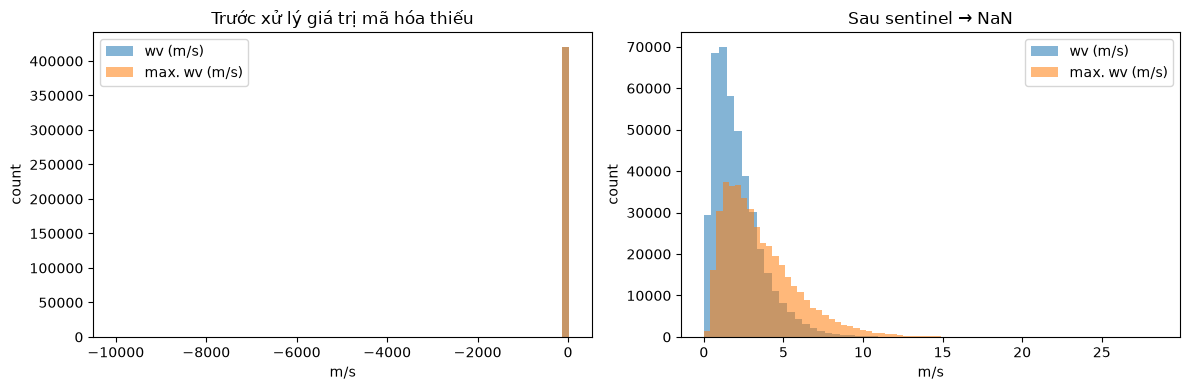

In [7]:
sentinel_clean_viz, _ = pp.handle_sentinels(raw_df)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, frame, title in zip(axes, [raw_df, sentinel_clean_viz], ["Trước xử lý giá trị mã hóa thiếu", "Sau sentinel → NaN"]):
    for column in SENTINEL_COLUMNS:
        ax.hist(frame[column].dropna(), bins=60, alpha=.55, label=column)
    ax.set_title(title); ax.set_xlabel("m/s"); ax.set_ylabel("số lượng"); ax.legend()
fig.tight_layout(); plt.show()

**Phát hiện.** `-9999` tạo đuôi phân phối phi vật lý trước xử lý và biến mất sau xử lý giá trị mã hóa thiếu.  
**Ảnh hưởng.** Nếu không xử lý trước lấy mẫu lại, trung bình/max theo giờ sẽ bị sai.  
**Quyết định.** Giữ thứ tự `handle_sentinels → resample_hourly` của quy trình.

## 3. So sánh Trước và Sau

INFO Timestamp cleaning: 420551 -> 420224 rows (dropped 327 exact duplicates, aggregated 0 conflicting groups)


INFO Sentinel handling: replaced 38 value(s) with NaN across ['wv (m/s)', 'max. wv (m/s)']


INFO Resampled to hourly: 70129 rows spanning 2009-01-01 00:00:00 to 2017-01-01 00:00:00


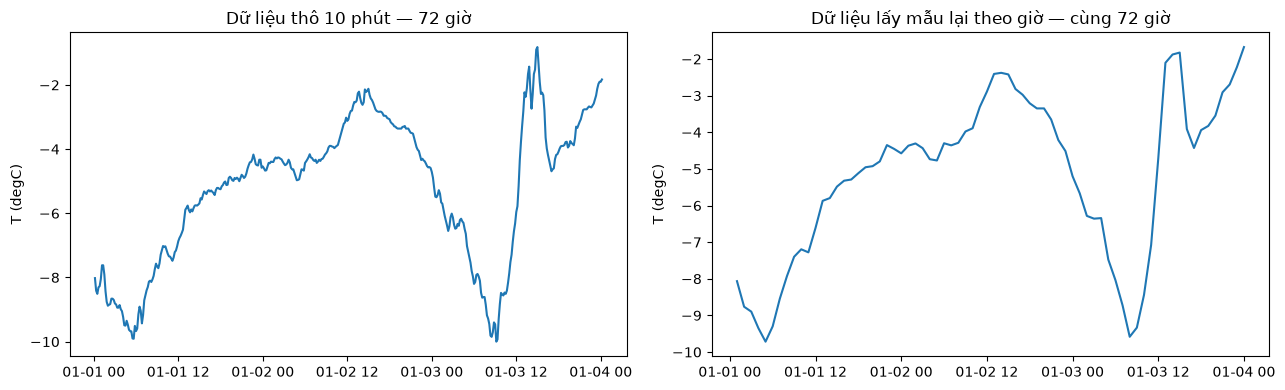

In [8]:
start = raw_df[pp.TIMESTAMP_COLUMN].min(); end = start + pd.Timedelta(hours=72)
raw_slice = raw_df[raw_df[pp.TIMESTAMP_COLUMN].between(start, end)]
clean_viz, _ = pp.clean_timestamps(raw_df)
sentinel_viz, _ = pp.handle_sentinels(clean_viz)
hourly_viz = pp.resample_hourly(sentinel_viz)
hour_slice = hourly_viz[hourly_viz[pp.TIMESTAMP_COLUMN].between(start, end)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(raw_slice[pp.TIMESTAMP_COLUMN], raw_slice[pp.TARGET_COLUMN]); axes[0].set_title("Dữ liệu thô 10 phút — 72 giờ")
axes[1].plot(hour_slice[pp.TIMESTAMP_COLUMN], hour_slice[pp.TARGET_COLUMN]); axes[1].set_title("Dữ liệu lấy mẫu lại theo giờ — cùng 72 giờ")
for ax in axes: ax.set_ylabel("T (degC)")
fig.tight_layout(); plt.show()

**Phát hiện.** lấy mẫu lại giữ xu hướng nhiệt độ trong cùng khoảng 72h và giảm mật độ điểm.  
**Ảnh hưởng.** mô hình nhận lưới theo giờ đều thay vì chuỗi 10 phút.  
**Quyết định.** Giữ cách tổng hợp riêng theo từng đặc trưng của quy trình.

In [9]:
train_df = pd.read_csv(OUTPUT_DIR / "train_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
val_df = pd.read_csv(OUTPUT_DIR / "val_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
test_df = pd.read_csv(OUTPUT_DIR / "test_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
processed_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

comparison = pd.DataFrame(
    {
        "raw": {
            "rows": raw_rows,
            "features": raw_cols - 1,  # excluding timestamp
            "sampling_frequency": f"{raw_mode_minutes:.0f} min",
        },
        "processed (train+val+test)": {
            "rows": len(processed_df),
            "features": len(pp.FEATURE_COLUMNS),
            "sampling_frequency": DATA_CONFIG["timestamp"]["resample_frequency"],
        },
    }
)
comparison

,raw,processed (train+val+test)
rows,420551,70129
features,14,18
sampling_frequency,10 min,1h


In [10]:
print(f"train rows: {len(train_df):,}")
print(f"val rows:   {len(val_df):,}")
print(f"test rows:  {len(test_df):,}")
print(f"sum:        {len(train_df) + len(val_df) + len(test_df):,}  (phải bằng số hàng đã xử lý ở trên)")

train rows: 49,090
val rows:   10,519
test rows:  10,520
sum:        70,129  (phải bằng số hàng đã xử lý ở trên)


## 4. Kiểm tra mốc thời gian

In [11]:
is_sorted = processed_df[pp.TIMESTAMP_COLUMN].is_monotonic_increasing
diffs = processed_df[pp.TIMESTAMP_COLUMN].diff().dropna()
is_hourly = (diffs == pd.Timedelta("1h")).all()

print(f"Tập huấn luyện+xác thực+kiểm thử gộp lại tăng dần: {is_sorted}")
print(f"Mọi bước thời gian liên tiếp đều đúng 1 giờ: {is_hourly}")
print(f"Các độ dài bước thời gian tìm thấy: {diffs.unique()}")

assert is_sorted, "Các mốc thời gian đã xử lý chưa được sắp xếp"
assert is_hourly, "Các mốc thời gian đã xử lý không nằm trên lưới theo giờ đều"
print("ĐẠT: các mốc thời gian đã được sắp xếp và cách nhau đúng một giờ, kể cả qua các khoảng trống của dữ liệu thô.")

Tập huấn luyện+xác thực+kiểm thử gộp lại tăng dần: True
Every consecutive step is exactly 1 hour: True
Unique step sizes found: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]
ĐẠT: các mốc thời gian đã được sắp xếp và cách nhau đúng một giờ, kể cả qua các khoảng trống của dữ liệu thô.


## 5. Kiểm tra Giá trị Thiếu

In [12]:
with open(PROJECT_ROOT / "artifacts" / "preprocessing" / "split_metadata.json") as f:
    import json
    split_metadata = json.load(f)

missing_summary = pd.DataFrame(
    {
        "input_features_NaN": split_metadata["missing_handling"]["remaining_missing_after_fill"],
        "target_T_degC_NaN": split_metadata["missing_handling"]["remaining_missing_target"],
    }
)
missing_summary

,input_features_NaN,target_T_degC_NaN
train,0,0
validation,156,15
test,910,73


In [13]:
input_feature_columns = [c for c in pp.FEATURE_COLUMNS if c != pp.TARGET_COLUMN]
actual_input_nan = {
    "train": int(train_df[input_feature_columns].isna().sum().sum()),
    "validation": int(val_df[input_feature_columns].isna().sum().sum()),
    "test": int(test_df[input_feature_columns].isna().sum().sum()),
}
print("Đặc trưng đầu vào: điền xuôi chỉ khép khoảng trống SHORT (<= "
      f"{DATA_CONFIG['missing']['forward_fill_max_hours']}giờ); khoảng trống LONG/CRITICAL được chủ ý")
print("được giữ NaN để đánh dấu mọi cửa sổ trượt chạm vào là không hợp lệ, không bao giờ bịa dữ liệu.")
print("Mục tiêu T (degC): NaN là KỲ VỌNG tại nơi dữ liệu thô có khoảng trống thật — giá trị được chủ ý")
print("giữ không bù thiếu; bước cửa sổ trượt phía sau phải loại các cửa sổ chồng lên các mốc thời gian này")
print("(cột missing_T_degC đánh dấu chính xác các vị trí đó).")
print("\nSố NaN của đặc trưng đầu vào theo tập (thực tế so với split_metadata.json):", actual_input_nan)

assert actual_input_nan == split_metadata["missing_handling"]["remaining_missing_after_fill"], (
    "CSV đã xử lý không khớp thống kê giá trị thiếu trong split_metadata.json"
)
assert actual_input_nan["train"] == 0, (
    "tập huấn luyện không có khoảng trống dài/nghiêm trọng — NaN còn lại tại đây là lỗi"
)
print("ĐẠT: số NaN của đặc trưng đầu vào khớp chính xác với split_metadata.json và tập huấn luyện không còn NaN "
      "(chỉ tập xác thực/kiểm thử còn NaN do khoảng trống dài, đúng như bảng khoảng trống của file thô).")

Đặc trưng đầu vào: điền xuôi chỉ khép khoảng trống SHORT (<= 3giờ); khoảng trống LONG/CRITICAL được chủ ý
được giữ NaN để đánh dấu mọi cửa sổ trượt chạm vào là không hợp lệ, không bao giờ bịa dữ liệu.
Mục tiêu T (degC): NaN là KỲ VỌNG tại nơi dữ liệu thô có khoảng trống thật — giá trị được chủ ý
giữ không bù thiếu; bước cửa sổ trượt phía sau phải loại các cửa sổ chồng lên các mốc thời gian này
(missing_T_degC marks exactly where).

Số NaN của đặc trưng đầu vào theo tập (thực tế so với split_metadata.json): {'train': 0, 'validation': 156, 'test': 910}
ĐẠT: số NaN của đặc trưng đầu vào khớp chính xác với split_metadata.json; tập huấn luyện không còn NaN, chỉ tập xác thực/kiểm thử còn NaN do khoảng trống dài.


## 6. Kiểm tra Chuẩn hóa

In [14]:
train_means = train_df[pp.FEATURE_COLUMNS].mean()
train_stds = train_df[pp.FEATURE_COLUMNS].std()

print(f"max |train mean| across features: {train_means.abs().max():.2e}  (expect ~0)")
print(f"max |train std - 1| across non-constant features: "
      f"{(train_stds[train_stds > 0] - 1).abs().max():.2e}  (expect ~0)")

constant_in_train = train_stds[train_stds == 0].index.tolist()
print(f"\nĐặc trưng có phương sai bằng 0 trong tập huấn luyện ({len(constant_in_train)}): {constant_in_train}")
print("Chỉ 18 đặc trưng mô hình được kiểm tra ở đây; các cột kiểm toán missing_* giữ dạng nhị phân và không chuẩn hóa.")

max |train mean| across features: 1.53e-08  (expect ~0)
max |train std - 1| across non-constant features: 1.02e-05  (expect ~0)

Đặc trưng có phương sai bằng 0 trong tập huấn luyện (0): []
Chỉ 18 đặc trưng mô hình được kiểm tra ở đây; các cột kiểm toán missing_* giữ dạng nhị phân và không chuẩn hóa.


In [15]:
if constant_in_train:
    activity = pd.DataFrame(
        {
            "val_rows_flagged": (val_df[constant_in_train] > 0).sum(),
            "test_rows_flagged": (test_df[constant_in_train] > 0).sum(),
        }
    )
    display(activity)
else:
    print("No constant-in-train indicators.")

No constant-in-train indicators.


## 7. Kiểm tra Rò rỉ Dữ liệu (rò rỉ dữ liệu)

In [16]:
train_start = pd.Timestamp(split_metadata["train"]["start"])
train_end = pd.Timestamp(split_metadata["train"]["end"])
val_start = pd.Timestamp(split_metadata["validation"]["start"])
val_end = pd.Timestamp(split_metadata["validation"]["end"])
test_start = pd.Timestamp(split_metadata["test"]["start"])
test_end = pd.Timestamp(split_metadata["test"]["end"])

print(f"train: {train_start} -> {train_end}")
print(f"val:   {val_start} -> {val_end}")
print(f"test:  {test_start} -> {test_end}")

assert train_end < val_start, "tập huấn luyện/xác thực bị chồng lấn!"
assert val_end < test_start, "tập xác thực/kiểm thử bị chồng lấn!"
print("ĐẠT: huấn luyện < xác thực < kiểm thử và không chồng lấn (chia theo thời gian).")

train: 2009-01-01 00:00:00 -> 2014-08-08 09:00:00
val:   2014-08-08 10:00:00 -> 2015-10-20 16:00:00
test:  2015-10-20 17:00:00 -> 2017-01-01 00:00:00
ĐẠT: huấn luyện < xác thực < kiểm thử và không chồng lấn (chia theo thời gian).


In [17]:
# Tính lại độc lập các khung huấn luyện/xác thực/kiểm thử trước chuẩn hóa (không qua preprocess())
# để chứng minh scaler.joblib được khớp chỉ trên tập HUẤN LUYỆN.
clean_df, _ = pp.clean_timestamps(raw_df)
sentinel_df, _ = pp.handle_sentinels(clean_df)
hourly_df = pp.add_missing_indicators(pp.add_time_features(pp.resample_hourly(sentinel_df)))
train_raw, val_raw, test_raw, _ = pp.temporal_split(hourly_df)
train_imp, val_imp, test_imp, _ = pp.impute_missing(train_raw, val_raw, test_raw)

scaler = joblib.load(PROJECT_ROOT / "artifacts" / "preprocessing" / "scaler.joblib")
recomputed_train_mean = train_imp[pp.FEATURE_COLUMNS].mean().to_numpy()
recomputed_train_std = train_imp[pp.FEATURE_COLUMNS].std(ddof=0).to_numpy()

print("scaler.mean_ khớp trung bình chỉ từ tập HUẤN LUYỆN được tính lại độc lập:",
      np.allclose(scaler.mean_, recomputed_train_mean, atol=1e-3, equal_nan=True))
print("scaler.scale_ khớp độ lệch chuẩn chỉ từ tập HUẤN LUYỆN được tính lại độc lập:",
      np.allclose(scaler.scale_, np.where(recomputed_train_std == 0, 1.0, recomputed_train_std), atol=1e-3))

INFO Timestamp cleaning: 420551 -> 420224 rows (dropped 327 exact duplicates, aggregated 0 conflicting groups)


INFO Sentinel handling: replaced 38 value(s) with NaN across ['wv (m/s)', 'max. wv (m/s)']


INFO Resampled to hourly: 70129 rows spanning 2009-01-01 00:00:00 to 2017-01-01 00:00:00


INFO Temporal split: train=49090 val=10519 test=10520 rows (train ends 2014-08-08T09:00:00, val ends 2015-10-20T16:00:00)


INFO Missing-value handling done. Remaining input NaNs (long/critical gaps, left as-is): train=0 val=156 test=910. Target left unimputed with NaNs: train=0 val=15 test=73


scaler.mean_ khớp trung bình chỉ từ tập HUẤN LUYỆN được tính lại độc lập: True
scaler.scale_ khớp độ lệch chuẩn chỉ từ tập HUẤN LUYỆN được tính lại độc lập: True


In [18]:
# Đối chiếu với phương án gây rò rỉ: khớp trên toàn bộ dữ liệu làm thay đổi thống kê.
from sklearn.preprocessing import StandardScaler

leaked_scaler = StandardScaler().fit(pd.concat([train_imp, val_imp, test_imp])[pp.FEATURE_COLUMNS])
mean_shift = np.nanmax(np.abs(leaked_scaler.mean_ - scaler.mean_))
print(f"Độ lệch lớn nhất giữa trung bình chỉ tập huấn luyện và trung bình fit trên toàn bộ dữ liệu: {mean_shift:.4f}")
print("Độ lệch khác 0 xác nhận rằng khớp trên toàn bộ dữ liệu sẽ làm rò rỉ thống kê xác thực/kiểm thử")
print("vào bước chuẩn hóa — quy trình này tránh điều đó bằng cách chỉ khớp trên tập huấn luyện.")

Độ lệch lớn nhất giữa trung bình chỉ tập huấn luyện và trung bình fit trên toàn bộ dữ liệu: 1.1582
Non-zero shift confirms fitting on the full dataset would have leaked val/test
statistics into normalization - which this pipeline avoids by fitting on train only.


## 7b. Minh họa Xử lý Khoảng trống

Bằng chứng cụ thể, ở mức từng hàng, cho hai quy tắc mức độ nghiêm trọng khoảng trống trong
`configs/data.yaml missing.*`: phần SHORT của một khoảng trống
(<= `forward_fill_max_hours`) được điền xuôi nhân quả; phần còn lại
vượt quá ngưỡng đó (LONG/CRITICAL) được để lại là `NaN`, và `WeatherForecastDataset`
(`src/data/dataset.py`) biến nó thành một cửa sổ trượt bị loại bỏ thay vì một
giá trị bịa đặt. Tái sử dụng `val_raw`/`val_imp` từ §7 ở trên - không chạy
quy trình mới, không chọn lọc ví dụ tổng hợp có chủ đích.

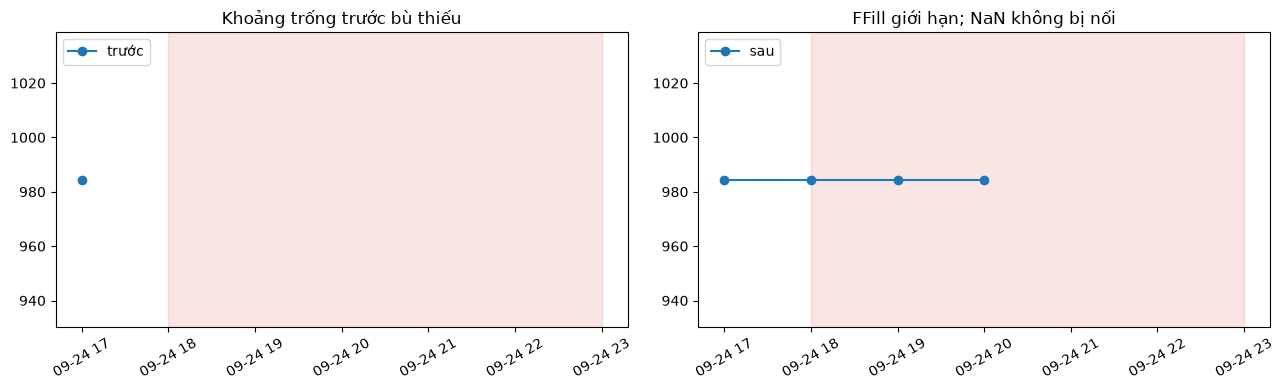

In [19]:
viz_features = [col for col in pp.FEATURE_COLUMNS if col != pp.TARGET_COLUMN]
viz_gap_start = int(val_raw.index[val_raw[viz_features].isna().any(axis=1)].min())
viz_col = next(col for col in viz_features if pd.isna(val_raw.loc[viz_gap_start, col]))
viz_idx = range(viz_gap_start - 1, viz_gap_start + DATA_CONFIG["missing"]["forward_fill_max_hours"] + 3)
illustration_viz = pd.DataFrame({"timestamp": val_raw.loc[viz_idx, pp.TIMESTAMP_COLUMN].values, "trước": val_raw.loc[viz_idx, viz_col].values, "sau": val_imp.loc[viz_idx, viz_col].values})
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(illustration_viz["timestamp"], illustration_viz["trước"], marker="o", label="trước")
axes[1].plot(illustration_viz["timestamp"], illustration_viz["sau"], marker="o", label="sau")
for ax in axes:
    ax.axvspan(illustration_viz["timestamp"].iloc[1], illustration_viz["timestamp"].iloc[-1], color="tab:red", alpha=.12)
    ax.legend(); ax.tick_params(axis="x", rotation=30)
axes[0].set_title("Khoảng trống trước bù thiếu"); axes[1].set_title("FFill giới hạn; NaN không bị nối")
fig.tight_layout(); plt.show()

**Phát hiện.** Giá trị cuối trước khoảng trống chỉ được chuyển tiếp trong giới hạn cấu hình; phần còn lại vẫn đứt tại NaN.  
**Ảnh hưởng.** Không có đường nội suy giả xuyên qua khoảng trống dài.  
**Quyết định.** Giữ nhân quả điền xuôi và cửa sổ rejection hiện tại.

In [20]:
from src.data.dataset import WeatherForecastDataset

# --- SHORT portion of a khoảng trống: forward-fill in action -------------------------
input_feature_columns = [c for c in pp.FEATURE_COLUMNS if c != pp.TARGET_COLUMN]
ffill_limit = DATA_CONFIG["missing"]["forward_fill_max_hours"]

pre_missing_idx = val_raw.index[val_raw[input_feature_columns].isna().any(axis=1)]
gap_start = int(pre_missing_idx.min())
example_col = next(c for c in input_feature_columns if pd.isna(val_raw.loc[gap_start, c]))
last_valid_value = val_raw.loc[gap_start - 1, example_col]

window_idx = range(gap_start - 1, gap_start + ffill_limit + 3)
illustration = pd.DataFrame(
    {
        "timestamp": val_raw.loc[window_idx, pp.TIMESTAMP_COLUMN].values,
        f"{example_col} — TRƯỚC (thô theo giờ, trước bù thiếu)": val_raw.loc[window_idx, example_col].values,
        f"{example_col} — SAU (sau bù thiếu)": val_imp.loc[window_idx, example_col].values,
    }
)
display(illustration)

filled_rows = illustration.iloc[1 : 1 + ffill_limit]
still_nan_rows = illustration.iloc[1 + ffill_limit :]
assert (filled_rows[f"{example_col} — SAU (sau bù thiếu)"] == last_valid_value).all(), (
    "các hàng đầu tiên theo forward_fill_max_hours phải được điền xuôi bằng giá trị quan sát cuối"
)
assert still_nan_rows[f"{example_col} — SAU (sau bù thiếu)"].isna().all(), (
    "các hàng vượt forward_fill_max_hours phải giữ NaN, không được bịa dữ liệu"
)
print(
    f"ĐẠT: {ffill_limit} giờ đầu của khoảng trống được điền xuôi bằng {last_valid_value:.3f} "
    f"({example_col}, giá trị cuối cùng quan sát được TRƯỚC khoảng trống); các giờ còn lại giữ là NaN "
    f"vì khoảng trống vượt quá forward_fill_max_hours={ffill_limit} giờ."
)

# --- LONG/CRITICAL remainder of the khoảng trống: window rejection -------------------
val_dataset = WeatherForecastDataset(val_df, pp.FEATURE_COLUMNS, pp.TARGET_COLUMN)
naive_max_windows = (
    len(val_df) - (DATA_CONFIG["window"]["input_length_hours"] + DATA_CONFIG["window"]["horizon_hours"]) + 1
)
print(
    f"\nTập xác thực: {naive_max_windows} vị trí bắt đầu cửa sổ khả dĩ nếu không có khoảng trống, "
    f"{len(val_dataset)} cửa sổ hợp lệ thực sự được giữ lại "
    f"({naive_max_windows - len(val_dataset)} bị loại vì chạm đầu vào/mục tiêu NaN)."
)

long_gap_timestamp = val_df.loc[val_df[input_feature_columns].isna().any(axis=1), pp.TIMESTAMP_COLUMN].iloc[0]
covering_windows = sum(
    1
    for i in range(len(val_dataset))
    if val_dataset.window_bounds(i)["input_start"] <= long_gap_timestamp <= val_dataset.window_bounds(i)["forecast_end"]
)
print(
    f"Các cửa sổ bao phủ mốc thời gian thuộc khoảng trống dài {long_gap_timestamp}: {covering_windows} "
    "(phải bằng 0 — đầu vào NaN tại mốc này loại mọi cửa sổ chạm vào nó)."
)
assert covering_windows == 0

,timestamp,"p (mbar) — TRƯỚC (thô theo giờ, trước bù thiếu)",p (mbar) — SAU (sau bù thiếu)
0,2014-09-24 17:00:00,984.5,984.5
1,2014-09-24 18:00:00,NaN,984.5
2,2014-09-24 19:00:00,NaN,984.5
3,2014-09-24 20:00:00,NaN,984.5
4,2014-09-24 21:00:00,NaN,NaN
5,2014-09-24 22:00:00,NaN,NaN
6,2014-09-24 23:00:00,NaN,NaN


ĐẠT: 3 giờ đầu của khoảng trống được điền xuôi bằng 984.500 (p (mbar), the last value observed BEFORE the gap); remaining giờ stay NaN because the gap exceeds forward_fill_max_hours=3h.

Tập xác thực: 10280 vị trí bắt đầu cửa sổ khả dĩ nếu không có khoảng trống, 10026 valid windows actually kept (254 bị loại vì chạm đầu vào/mục tiêu NaN).
Các cửa sổ bao phủ mốc thời gian thuộc khoảng trống dài 2014-09-24 21:00:00: 0 (must be 0 - that timestamp's NaN input rejects every window touching it).


**Phát hiện.** Trong một khoảng trống thực tế ở tập xác thực (rộng 16 giờ thô,
Notebook 01 §4), số giờ đầu tiên bằng `forward_fill_max_hours` được
điền xuôi từ giá trị cuối cùng quan sát được *trước* khoảng trống - không bao giờ lấy từ
tương lai - và mọi giờ vượt quá giới hạn đó được cố tình để lại là `NaN`,
không bị bịa đặt. Ở mức cửa sổ, không có cửa sổ trượt nào giữ lại một khoảng
chạm vào mốc thời gian `NaN` đó: `WeatherForecastDataset` loại bỏ tất cả chúng,
nên mô hình không bao giờ huấn luyện hay đánh giá trên một chuỗi bịa đặt hoặc
bị cắt xén.

**Vì sao điều này quan trọng.** Đây chính là cơ chế giải quyết phát hiện về
khoảng trống SHORT/LONG/CRITICAL ở Notebook 01 §4: một khoảng trống SHORT trở nên vô hình
đối với mô hình (được đóng lại một cách nhân quả); một khoảng trống LONG/CRITICAL cũng trở nên vô hình, nhưng
bằng cách loại trừ (bỏ cửa sổ) chứ không phải bằng cách bịa đặt.

## 7c. Chuẩn hóa Trước / Sau: °C → điểm z

Cùng hàng, cùng cột, hai đơn vị: `train_imp` (§7, chưa chuẩn hóa, lấy thẳng
từ `impute_missing`, vẫn ở đơn vị vật lý - độ C cho nhiệt độ) so với
`train_df` (§3, sau `scale_features`, đã chuẩn hóa). `StandardScaler` đã khớp
(được chứng minh chỉ khớp trên huấn luyện ở §7) chính là thứ biến cái này thành
cái kia.

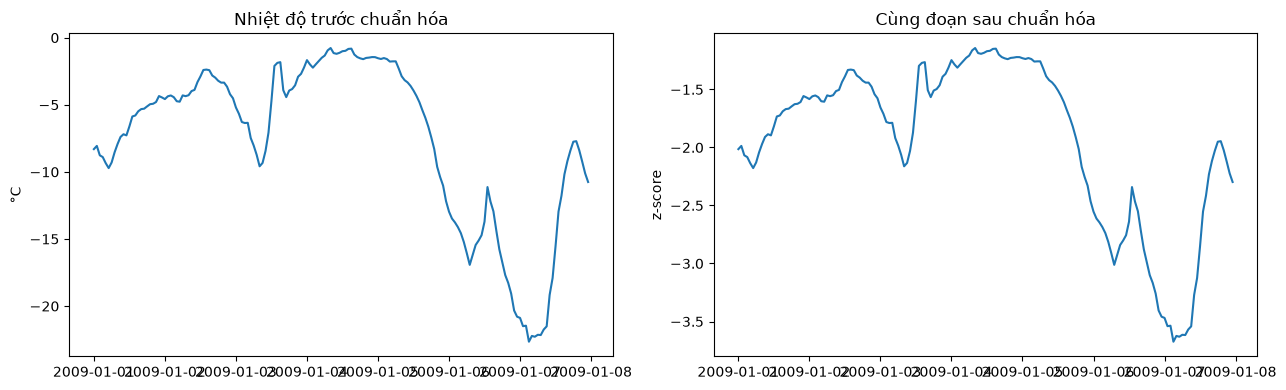

In [21]:
segment = slice(0, 168)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_imp[pp.TIMESTAMP_COLUMN].iloc[segment], train_imp[pp.TARGET_COLUMN].iloc[segment]); axes[0].set_title("Nhiệt độ trước chuẩn hóa"); axes[0].set_ylabel("°C")
axes[1].plot(train_df[pp.TIMESTAMP_COLUMN].iloc[segment], train_df[pp.TARGET_COLUMN].iloc[segment]); axes[1].set_title("Cùng đoạn sau chuẩn hóa"); axes[1].set_ylabel("z-score")
fig.tight_layout(); plt.show()

**Phát hiện.** Hình dạng chuỗi được giữ nguyên, chỉ đổi đơn vị từ °C sang điểm z.  
**Ảnh hưởng.** Trực quan hóa/báo cáo cần inverse-transform khi diễn giải vật lý.  
**Quyết định.** Bộ chuẩn hóa tiếp tục chỉ được khớp trên tập huấn luyện.

In [22]:
before_after = pd.DataFrame(
    {
        "timestamp": train_imp[pp.TIMESTAMP_COLUMN].iloc[:5].values,
        "T (degC) — TRƯỚC (đơn vị gốc)": train_imp[pp.TARGET_COLUMN].iloc[:5].values,
        "T (degC) — SAU (điểm z)": train_df[pp.TARGET_COLUMN].iloc[:5].values,
    }
)
before_after["điểm z tính lại (áp dụng scaler.mean_/scale_ thủ công)"] = (
    before_after["T (degC) — TRƯỚC (đơn vị gốc)"] - scaler.mean_[pp.TARGET_INDEX]
) / scaler.scale_[pp.TARGET_INDEX]
display(before_after)

assert np.allclose(
    before_after["T (degC) — SAU (điểm z)"],
    before_after["điểm z tính lại (áp dụng scaler.mean_/scale_ thủ công)"],
    atol=1e-4,
)
print("ĐẠT: SAU == (TRƯỚC - scaler.mean_[TARGET_INDEX]) / scaler.scale_[TARGET_INDEX] chính xác.")

,timestamp,T (degC) — TRƯỚC (đơn vị gốc),T (degC) — SAU (điểm z),điểm z tính lại (áp dụng scaler.mean_/scale_ thủ công)
0,2009-01-01 00:00:00,-8.304000,-2.014297,-2.014297
1,2009-01-01 01:00:00,-8.065000,-1.986651,-1.986651
2,2009-01-01 02:00:00,-8.763333,-2.067430,-2.067430
3,2009-01-01 03:00:00,-8.896667,-2.082853,-2.082853
4,2009-01-01 04:00:00,-9.348333,-2.135099,-2.135099


ĐẠT: SAU == (TRƯỚC - scaler.mean_[TARGET_INDEX]) / scaler.scale_[TARGET_INDEX] chính xác.


**Phát hiện.** Cột TRƯỚC ở đơn vị vật lý (độ C); cột SAU không có đơn vị,
trung bình-0/độ lệch chuẩn-1 theo cấu trúc trên huấn luyện (§6). Tính lại phép biến đổi bằng tay từ
`scaler.mean_`/`scaler.scale_` tái tạo chính xác cột SAU của quy trình, và §7
ở trên đã chứng minh các giá trị `mean_`/`scale_` đó chỉ đến từ các hàng huấn luyện - nên
"điểm z" ở đây không bao giờ bị nhiễm bởi thống kê của xác thực/kiểm thử.

## 8. Dòng thời gian Chia tách (tập dữ liệu)

Các vùng huấn luyện/xác thực/kiểm thử theo thời gian được vẽ trực tiếp lên chuỗi mục tiêu
theo giờ trước khi chuẩn hóa - cùng các ranh giới được ghi lại trong
`split_metadata.json` (§7) và dùng để xây dựng `train_df`/`val_df`/`test_df`
ở §3.

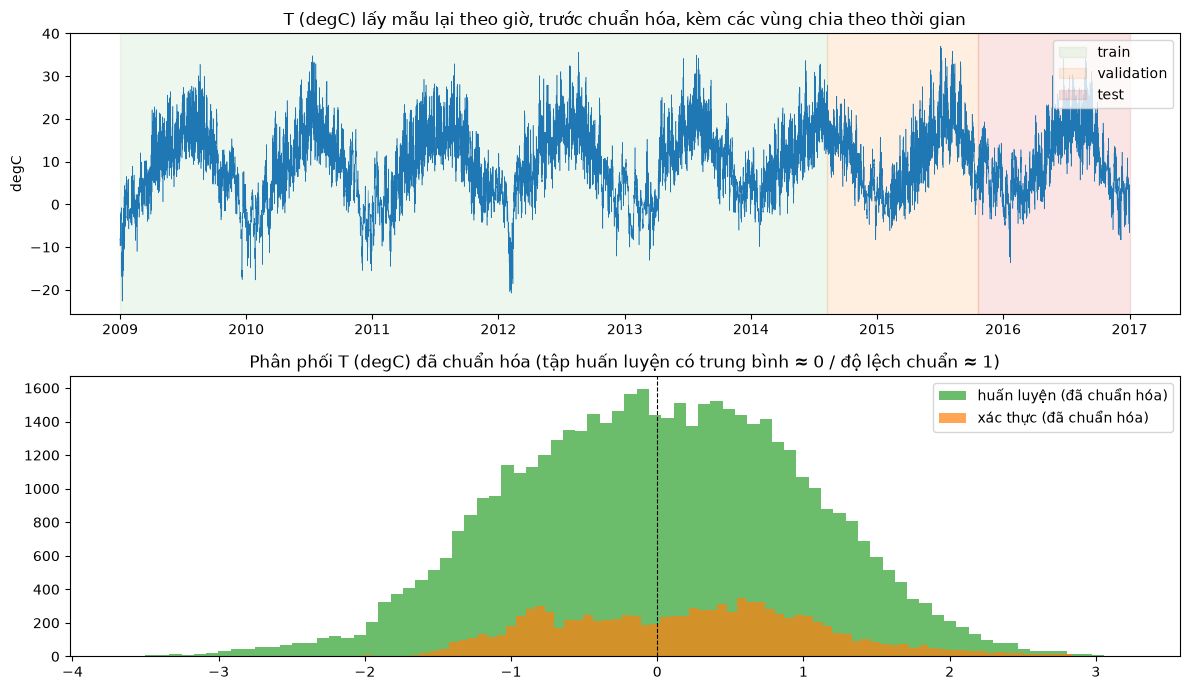

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(hourly_df[pp.TIMESTAMP_COLUMN], hourly_df[pp.TARGET_COLUMN], linewidth=0.4, color="tab:blue")
axes[0].axvspan(train_start, train_end, color="tab:green", alpha=0.08, label="train")
axes[0].axvspan(val_start, val_end, color="tab:orange", alpha=0.12, label="validation")
axes[0].axvspan(test_start, test_end, color="tab:red", alpha=0.12, label="test")
axes[0].set_title("T (degC) lấy mẫu lại theo giờ, trước chuẩn hóa, kèm các vùng chia theo thời gian")
axes[0].set_ylabel("degC")
axes[0].legend(loc="upper right")

axes[1].hist(train_df[pp.TARGET_COLUMN].dropna(), bins=80, color="tab:green", alpha=0.7, label="huấn luyện (đã chuẩn hóa)")
axes[1].hist(val_df[pp.TARGET_COLUMN].dropna(), bins=80, color="tab:orange", alpha=0.7, label="xác thực (đã chuẩn hóa)")
axes[1].set_title("Phân phối T (degC) đã chuẩn hóa (tập huấn luyện có trung bình ≈ 0 / độ lệch chuẩn ≈ 1)")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].legend()

fig.tight_layout()
plt.show()

## 9. Mẫu đặc trưng đã xử lý

In [24]:
train_df[[pp.TIMESTAMP_COLUMN] + pp.FEATURE_COLUMNS[:8]].head(10)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar)
0,2009-01-01 00:00:00,0.948907,-2.014297,-2.074466,-1.968587,1.083659,-1.314739,-1.497932,-0.790657
1,2009-01-01 01:00:00,0.948545,-1.986651,-2.046505,-1.931547,1.092974,-1.306490,-1.482811,-0.790727
2,2009-01-01 02:00:00,0.975079,-2.067430,-2.128743,-2.038843,1.068674,-1.329717,-1.525958,-0.790727
3,2009-01-01 03:00:00,1.004227,-2.082853,-2.146338,-2.064173,1.048423,-1.334058,-1.535854,-0.788987
4,2009-01-01 04:00:00,1.024931,-2.135099,-2.199698,-2.144227,0.998809,-1.348385,-1.565146,-0.784464
5,2009-01-01 05:00:00,1.067346,-2.177706,-2.245215,-2.196561,0.998809,-1.359673,-1.584147,-0.786204
6,2009-01-01 06:00:00,1.121018,-2.129315,-2.201036,-2.134908,1.004884,-1.346432,-1.562375,-0.785856
7,2009-01-01 07:00:00,1.209063,-2.041981,-2.120519,-2.017097,1.039310,-1.322553,-1.516853,-0.786899
8,2009-01-01 08:00:00,1.292486,-1.970649,-2.055876,-1.937760,1.012985,-1.302148,-1.485582,-0.780984
9,2009-01-01 09:00:00,1.351786,-1.909535,-1.999648,-1.879213,0.962358,-1.283697,-1.461435,-0.772634


In [25]:
indicator_preview = train_df[[pp.TIMESTAMP_COLUMN] + pp.DIAGNOSTIC_INDICATOR_COLUMNS[:6]].head(3)
assert set(train_df[pp.DIAGNOSTIC_INDICATOR_COLUMNS].stack().unique()) <= {0.0, 1.0}
indicator_preview

,Date Time,missing_p_mbar,missing_T_degC,missing_Tpot_K,missing_Tdew_degC,missing_rh_pct,missing_VPmax_mbar
0,2009-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0
1,2009-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0
2,2009-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0


## 9b. siêu dữ liệu: Thông tin bộ chuẩn hóa & đặc trưng lược đồ

Mọi thứ mà một bên tiêu thụ phía sau cần để *sử dụng* bộ dữ liệu đã xử lý
một cách đúng đắn mà không cần suy ra lại: những đặc trưng nào tồn tại, theo thứ tự nào, và
chính xác mỗi đặc trưng đã được chuẩn hóa như thế nào. Cả hai đều lấy trực tiếp từ các file mà
`preprocess()` ghi ra (khối `scaling` trong `split_metadata.json` và `feature_schema.json`),
không được tính lại ở đây.

In [26]:
scaler_info = split_metadata["scaling"]
print(
    f"method={scaler_info['method']}  fit_scope={scaler_info['fit_scope']}  "
    f"n_features={scaler_info['n_features']}  n_samples_seen={scaler_info['n_samples_seen']}"
)
assert scaler_info["n_samples_seen"] == len(train_df)
assert scaler.n_features_in_ == len(pp.FEATURE_COLUMNS) == 18

scaler_info_table = pd.DataFrame(scaler_info["per_feature"]).T
scaler_info_table.index.name = "feature"
display(scaler_info_table.head(10))

with open(OUTPUT_DIR / "feature_schema.json", encoding="utf-8") as f:
    feature_schema = json.load(f)
print(
    f"\nfeature_schema.json: n_features={feature_schema.get('n_features')}, "
    f"target={feature_schema.get('target')}"
)
assert feature_schema["ordered_features"] == pp.FEATURE_COLUMNS
assert not any(c.startswith("missing_") for c in feature_schema["ordered_features"])
assert feature_schema["target"]["index"] == pp.TARGET_INDEX == 1
feature_schema_table = pd.DataFrame({"feature": feature_schema["ordered_features"]})
feature_schema_table.index.name = "index"
feature_schema_table

method=standard_scaler  fit_scope=train_only  n_features=18  n_samples_seen=49090


,mean,scale
feature,,
p (mbar),988.660466,8.291157
T (degC),9.109561,8.644982
Tpot (K),283.195955,8.714511
Tdew (degC),4.609847,6.974469
rh (%),75.942473,16.460460
VPmax (mbar),13.354348,7.677837
VPact (mbar),9.364892,4.210399
VPdef (mbar),3.989373,4.790158
sh (g/kg),5.918537,2.672592



feature_schema.json: n_features=18, target={'name': 'T (degC)', 'index': 1, 'dtype': 'float32', 'unit': 'degC'}


,feature
index,
0,p (mbar)
1,T (degC)
2,Tpot (K)
3,Tdew (degC)
4,rh (%)
5,VPmax (mbar)
6,VPact (mbar)
7,VPdef (mbar)
8,sh (g/kg)


**Phát hiện.** `scaler_info['fit_scope'] == "train_only"` và
`n_samples_seen` bằng đúng số hàng huấn luyện từ §3 - một xác nhận độc lập,
dựa trên file, cho việc khớp chỉ trên huấn luyện đã được chứng minh bằng
chương trình ở §7. `ordered_features` trong `feature_schema.json` chính xác
là `pp.FEATURE_COLUMNS`, nên một bên tiêu thụ phía sau (ví dụ
`WeatherForecastDataset`) có thể tái tạo lại đúng thứ tự đặc trưng và chỉ số
mục tiêu mà không cần import trực tiếp `src/data/preprocessing.py` - chỉ cần
hai file siêu dữ liệu này.

## Tóm tắt

- Dữ liệu thô 10 phút (420.551 hàng, 14 cột số) được làm sạch, lấy mẫu lại
  thành một lưới theo giờ đều đặn nghiêm ngặt, được bổ sung các đặc trưng thời gian dạng
  chu kỳ và 14 chỉ báo thiếu dữ liệu chỉ phục vụ kiểm toán, chia tách theo thời gian 70/15/15,
  được bù thiếu mà không vượt qua ranh giới tập dữ liệu; `StandardScaler` chỉ khớp 18 đặc trưng mô hình
  đặc trưng trên huấn luyện, còn indicators giữ nhị phân 0/1.
- Bộ dữ liệu đã xử lý giữ 18 mô hình đặc trưng đã chuẩn hóa và 14 `missing_*` cột kiểm toán
  nhị phân không chuẩn hóa; mục tiêu `T (degC)` vẫn ở chỉ số 1 và khớp với hợp đồng đã khóa trong
  `artifacts/preprocessing/feature_schema.json` và đã sẵn sàng cho bước
  tiếp theo: xây dựng cửa sổ trượt 168 giờ đầu vào / 72 giờ đầu ra.
- Mọi vấn đề được nêu trong `01_data_check.ipynb` (mốc thời gian không sắp xếp/trùng lặp,
  giá trị mã hóa thiếu `-9999`, nhịp dữ liệu thô, khoảng trống SHORT/LONG/CRITICAL,
  tính mùa vụ theo ngày/năm, rủi ro rò rỉ bộ chuẩn hóa) đều có bằng chứng
  Trước/Sau hoặc phạm vi khớp tương ứng ở trên - xem bảng tóm tắt ở đầu
  notebook này để biết chính xác phần nào trả lời phát hiện nào.